# Load data

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
import random
from sklearn.metrics import r2_score
df = pd.read_csv("adjprice.csv")
df

,Date,0111145D US Equity,0202445Q US Equity,0203524D US Equity,0226226D US Equity,0376152D US Equity,0440296D US Equity,0544749D US Equity,0574018D US Equity,0598884D US Equity,...,YNR US Equity,YRCW US Equity,YUM US Equity,YUMC US Equity,ZBH US Equity,ZETHQ US Equity,ZION US Equity,ZRN US Equity,ZTS US Equity,ZTS-W US Equity
0,19930907,13.2719,13.6829,8.4429,8.1042,11.000,57.3245,17.8887,6.8315,28.1246,...,NaN,144439.5121,NaN,NaN,NaN,6.875,7.1675,30.7970,NaN,NaN
1,19930908,13.3263,13.5315,8.2147,7.9590,11.000,57.2096,17.8064,6.8315,27.5051,...,NaN,143691.1208,NaN,NaN,NaN,6.750,6.9766,30.0188,NaN,NaN
2,19930909,13.7070,13.3800,8.7852,8.0627,11.125,59.1625,17.6831,6.8315,27.7529,...,NaN,143691.1208,NaN,NaN,NaN,6.625,6.9554,30.0188,NaN,NaN
3,19930910,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN
4,19930911,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9454,20190727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.3500,114.02,45.31,134.50,NaN,45.1600,NaN,115.11,NaN
9455,20190728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.3500,114.02,45.31,134.50,NaN,45.1600,NaN,115.11,NaN
9456,20190729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.1800,114.10,45.43,134.53,NaN,44.6500,NaN,115.55,NaN
9457,20190730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.1800,113.24,44.00,136.67,NaN,45.4800,NaN,115.79,NaN


# Stock Price Trends Over Time

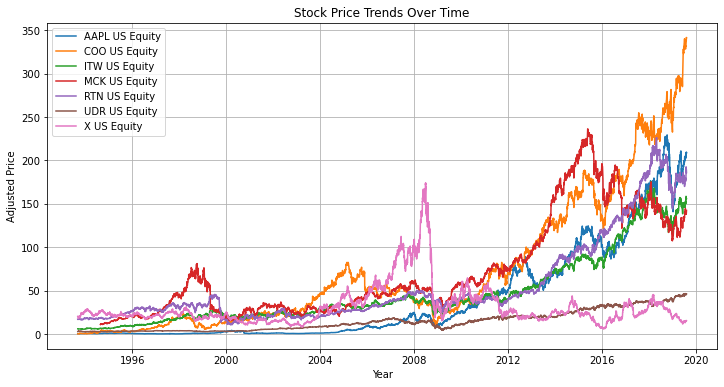

In [63]:
# Convert 'Date' to datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

# Select a few stocks to visualize
stocks_to_plot = ['AAPL US Equity', 'COO US Equity', 'ITW US Equity', 'MCK US Equity', 'RTN US Equity', 'UDR US Equity', 'X US Equity']

plt.figure(figsize=(12, 6))
for stock in stocks_to_plot:
    if stock in df.columns:
        plt.plot(df['Date'], df[stock], label=stock)

plt.title('Stock Price Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Adjusted Price')
plt.legend()
plt.grid(True)
plt.savefig('stock_price_over_time.png', transparent=True)
plt.show()

In [64]:
df.describe()

,0111145D US Equity,0202445Q US Equity,0203524D US Equity,0226226D US Equity,0376152D US Equity,0440296D US Equity,0544749D US Equity,0574018D US Equity,0598884D US Equity,0772031D US Equity,...,YNR US Equity,YRCW US Equity,YUM US Equity,YUMC US Equity,ZBH US Equity,ZETHQ US Equity,ZION US Equity,ZRN US Equity,ZTS US Equity,ZTS-W US Equity
count,6954.000000,6222.000000,6954.000000,5856.000000,5124.000000,1098.000000,4758.000000,5490.000000,2196.000000,5203.000000,...,1221.000000,9459.000000,7988.000000,1018.000000,6581.000000,2562.000000,9459.000000,1830.000000,2373.000000,95.000000
mean,27.322987,46.999521,15.022384,23.477752,17.827976,98.748765,24.584672,23.179905,35.747307,10.497943,...,44.062574,106369.946519,30.069563,36.797030,74.560986,6.392872,34.278650,25.435501,54.937893,30.972211
std,11.726762,20.481534,6.365943,18.761716,12.514460,41.710473,9.956974,17.120526,14.427557,10.674613,...,9.094332,112806.538215,25.804126,5.833090,28.174392,4.821393,17.359362,8.171267,23.145614,0.164389
min,10.129900,13.131700,3.651000,4.201000,3.250000,50.171300,11.052100,6.122500,17.400200,0.878700,...,21.306900,2.660000,3.290000,23.996900,23.548000,0.001000,5.892600,15.630700,24.886600,29.980000
25%,19.460600,31.485100,9.846950,8.771025,8.625000,69.896900,18.989050,11.814300,24.456400,3.372500,...,38.460700,18.215000,8.311500,33.673500,53.382900,0.410000,20.739500,19.521200,34.950800,31.000000
50%,24.131900,44.780100,13.846650,16.249250,12.362500,77.398900,22.667800,17.085100,28.849850,5.897900,...,47.656400,101587.581400,20.232750,37.446850,70.553500,7.375000,32.459300,23.946400,47.234300,31.000000
75%,34.034800,62.828125,20.308700,34.030700,24.922500,135.685700,25.792350,31.275300,48.180600,13.142700,...,48.062500,159917.470700,47.366100,40.948925,99.259700,10.375000,46.122700,28.318700,71.563400,31.000000
max,57.253600,106.950000,38.791800,78.298300,51.470000,173.500000,70.470000,62.484400,69.562500,50.993900,...,72.891100,475500.047600,114.100000,47.812800,136.670000,22.875000,77.687200,47.625000,115.940000,31.480000


# Missing Data Heatmap

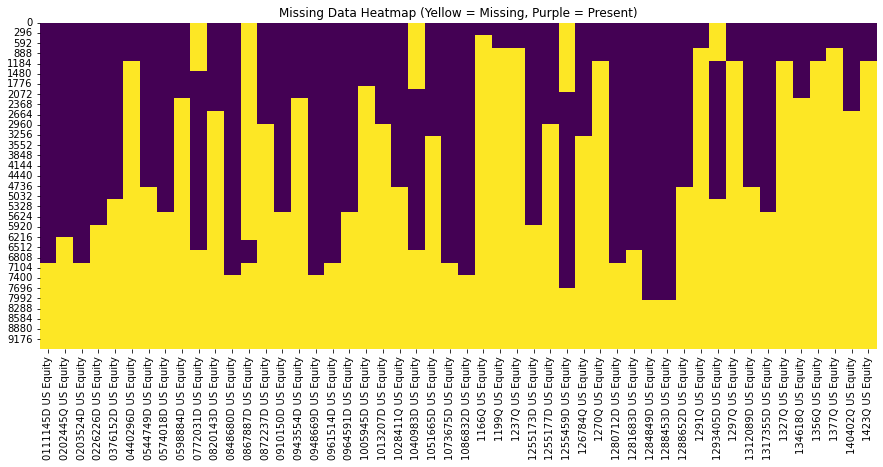

In [65]:
# Visualize missing data for the first 50 stocks as a sample
plt.figure(figsize=(15, 6))
sns.heatmap(df.iloc[:, 1:51].isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Yellow = Missing, Purple = Present)')
plt.show()

# Keep stocks with 90% coverage

In [66]:
coverage = df.notna().mean()
df = df.loc[:, coverage >= 0.9]
df

,Date,1436513D US Equity,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
0,1993-09-07,3.0147,13.6285,0.8044,NaN,3.750,3.2659,16.9898,2.3712,2.9608,...,6.7803,20.5434,6.9696,12.3149,2.5342,8.0198,5.3036,20.5503,144439.5121,7.1675
1,1993-09-08,2.9691,13.3718,0.8197,NaN,4.375,3.2037,17.0863,2.4320,2.9025,...,6.6519,20.3829,6.9696,12.2506,2.4735,8.0815,5.1244,20.5503,143691.1208,6.9766
2,1993-09-09,3.0278,13.4652,0.7967,NaN,4.375,3.2659,17.1828,2.3104,3.0046,...,6.5878,20.4632,6.9326,12.2506,2.5797,8.0044,5.1244,20.3040,143691.1208,6.9554
3,1993-09-10,3.0278,13.3952,0.8044,NaN,4.125,3.2659,16.6036,2.3712,3.1067,...,6.6947,20.7039,7.0065,12.2506,2.7087,8.0969,5.3036,20.4096,145187.9033,7.2099
4,1993-09-11,3.0278,13.3952,0.8044,NaN,4.125,3.2659,16.6036,2.3712,3.1067,...,6.6947,20.7039,7.0065,12.2506,2.7087,8.0969,5.3036,20.4096,145187.9033,7.2099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9454,2019-07-27,NaN,23.1300,207.7400,86.12,272.660,87.7500,NaN,311.2700,121.8000,...,26.2100,15.1900,60.5100,57.5900,120.7700,74.8100,56.0200,34.4300,3.3500,45.1600
9455,2019-07-28,NaN,23.1300,207.7400,86.12,272.660,87.7500,NaN,311.2700,121.8000,...,26.2100,15.1900,60.5100,57.5900,120.7700,74.8100,56.0200,34.4300,3.3500,45.1600
9456,2019-07-29,NaN,23.1200,209.6800,87.23,275.930,88.5500,NaN,307.2200,121.2100,...,25.8400,15.2700,60.9800,57.5900,120.5500,75.3400,56.3700,33.9400,3.1800,44.6500
9457,2019-07-30,NaN,23.0400,208.7800,88.72,279.230,88.3100,NaN,303.6400,120.9600,...,26.0900,15.7100,60.5900,57.5900,119.5100,75.3500,56.6700,32.7800,3.1800,45.4800


# Drop any rows with N/A values

In [67]:
df_clean = df.dropna()
df_clean

,Date,1436513D US Equity,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
904,1996-02-28,3.9666,21.4810,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
905,1996-02-29,4.0085,22.3658,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
906,1996-03-01,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
907,1996-03-02,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
908,1996-03-03,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,2016-09-19,45.4500,20.9622,109.5665,80.0464,125.100,39.7491,16.9158,99.6800,59.8806,...,27.9673,16.5371,39.0638,32.4004,51.0060,76.8618,58.8778,24.0173,11.7500,28.9620
8414,2016-09-20,45.4500,21.1414,109.5569,78.9119,125.100,39.6538,16.9256,100.6200,59.7655,...,27.8095,16.3699,38.9138,32.4390,50.4720,75.6790,58.7299,23.9198,11.6800,28.9329
8415,2016-09-21,45.4500,21.6565,109.5376,79.8156,126.900,39.9780,18.3918,107.7800,60.6859,...,28.1623,17.6094,39.8792,33.1146,50.7771,76.3758,59.0454,24.2367,11.9000,29.0492
8416,2016-09-22,45.4500,21.9028,110.5698,80.3636,126.370,40.2641,18.2344,107.9200,61.0502,...,29.7774,17.9046,40.2072,33.4813,50.9583,76.5959,59.1637,24.4074,12.2600,29.3301


# Remove duplicated rows (weekends and public holidays) and non-publicly traded entities (numerical tickers)

In [68]:
df_cleaned = df_clean[~df_clean.iloc[:, 1:].duplicated()]
df_cleaned = df_cleaned.drop(df.columns[1], axis=1)
df_cleaned

,Date,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
904,1996-02-28,21.4810,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,9.5428,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
905,1996-02-29,22.3658,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,9.3605,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
906,1996-03-01,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,9.4212,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
909,1996-03-04,22.8574,0.8280,2.9279,6.063,5.7916,22.5335,3.9987,6.4321,9.4212,...,8.1464,23.1162,8.6955,19.5936,5.2352,10.9350,5.7542,38.9530,71232.7264,13.5369
910,1996-03-05,22.8082,0.8398,3.0050,6.063,5.7091,22.8261,4.0450,6.8259,9.2997,...,8.0538,23.0299,8.7170,19.6281,5.7588,11.1417,5.7542,39.7834,70423.2636,13.6052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,2016-09-19,20.9622,109.5665,80.0464,125.100,39.7491,16.9158,99.6800,59.8806,39.4369,...,27.9673,16.5371,39.0638,32.4004,51.0060,76.8618,58.8778,24.0173,11.7500,28.9620
8414,2016-09-20,21.1414,109.5569,78.9119,125.100,39.6538,16.9256,100.6200,59.7655,39.4089,...,27.8095,16.3699,38.9138,32.4390,50.4720,75.6790,58.7299,23.9198,11.6800,28.9329
8415,2016-09-21,21.6565,109.5376,79.8156,126.900,39.9780,18.3918,107.7800,60.6859,40.0260,...,28.1623,17.6094,39.8792,33.1146,50.7771,76.3758,59.0454,24.2367,11.9000,29.0492
8416,2016-09-22,21.9028,110.5698,80.3636,126.370,40.2641,18.2344,107.9200,61.0502,40.1849,...,29.7774,17.9046,40.2072,33.4813,50.9583,76.5959,59.1637,24.4074,12.2600,29.3301


# Get tickers

In [69]:
tickers = []
for col in df_cleaned.columns[2:]:
    tickers.append(col.split()[0])

ticker_df = pd.DataFrame({"Ticker": tickers})
ticker_df

,Ticker
0,AAPL
1,ABC
2,ABMD
3,ABT
4,ABX
...,...
450,XOM
451,XRAY
452,XRX
453,YRCW


# Load dataset containing tickers and their corresponding sectors

In [70]:
sectors = pd.read_csv("SP500.csv")
sector_df = sectors.rename(columns={"Symbol": "Ticker"})
sector_df

,Ticker,Name,Sector
0,MMM,3M Company,Industrials
1,AOS,A.O. Smith Corp,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie Inc.,Health Care
4,ACN,Accenture plc,Information Technology
...,...,...,...
500,XYL,Xylem Inc.,Industrials
501,YUM,Yum! Brands Inc,Consumer Discretionary
502,ZBH,Zimmer Biomet Holdings,Health Care
503,ZION,Zions Bancorp,Financials


# Merge ticker-sector dataframe with tickers dataset

In [71]:
ticker_df = ticker_df.merge(sector_df, on="Ticker", how="left")
ticker_df

,Ticker,Name,Sector
0,AAPL,Apple Inc.,Information Technology
1,ABC,AmerisourceBergen Corp,Health Care
2,ABMD,NaN,NaN
3,ABT,Abbott Laboratories,Health Care
4,ABX,NaN,NaN
...,...,...,...
450,XOM,Exxon Mobil Corp.,Energy
451,XRAY,Dentsply Sirona,Health Care
452,XRX,Xerox Corp.,Information Technology
453,YRCW,NaN,NaN


# Number of unclassified tickers

In [72]:
ticker_df["Name"].isna().sum()

113

# Fill N/A sectors with "unknown"

In [73]:
ticker_df["Sector"] = ticker_df["Sector"].fillna("Unknown")
ticker_df

,Ticker,Name,Sector
0,AAPL,Apple Inc.,Information Technology
1,ABC,AmerisourceBergen Corp,Health Care
2,ABMD,NaN,Unknown
3,ABT,Abbott Laboratories,Health Care
4,ABX,NaN,Unknown
...,...,...,...
450,XOM,Exxon Mobil Corp.,Energy
451,XRAY,Dentsply Sirona,Health Care
452,XRX,Xerox Corp.,Information Technology
453,YRCW,NaN,Unknown


# Convert raw prices into returns

In [74]:
# Set Date as the index first
df_with_index = df_cleaned.set_index('Date')

# Calculate returns 
returns = df_with_index.pct_change().dropna()

returns

,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,ADP US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,0.041190,-0.009025,0.000000,0.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,0.006595,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,0.015284,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,0.000000,-0.012732,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,-0.002152,0.014251,0.026333,0.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,0.000000,0.021318,-0.011364,0.005045
1996-03-06,0.006467,-0.016432,0.008552,0.000000,-0.002890,0.000000,-0.030532,-0.028846,0.006538,-0.003214,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,0.000000,-0.006689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,-0.008476,-0.011661,-0.010106,0.001361,-0.004538,-0.008650,0.007581,0.006608,0.003568,-0.002189,...,0.007355,0.056569,0.011651,0.003590,0.002437,-0.002379,0.001509,0.005101,0.008584,0.000000
2016-09-20,0.008549,-0.000088,-0.014173,0.000000,-0.002398,0.000579,0.009430,-0.001922,-0.000710,0.014210,...,-0.005642,-0.010111,-0.003840,0.001191,-0.010469,-0.015389,-0.002512,-0.004060,-0.005957,-0.001005
2016-09-21,0.024365,-0.000176,0.011452,0.014388,0.008176,0.086626,0.071159,0.015400,0.015659,0.012416,...,0.012686,0.075718,0.024809,0.020827,0.006045,0.009207,0.005372,0.013248,0.018836,0.004020


# Use K-means to check for clusters

In [75]:
# Calculate features for every stock
stock_returns = returns.mean() * 252
stock_volatility = returns.std() * np.sqrt(252)

# Combine into a feature dataframe
eda_features = pd.DataFrame({
    'Return': stock_returns,
    'Volatility': stock_volatility
})

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(eda_features)

eda_features

,Return,Volatility
AA US Equity,0.085775,0.412675
AAPL US Equity,0.345252,0.464186
ABC US Equity,0.216100,0.333084
ABMD US Equity,0.351704,0.644110
ABT US Equity,0.128663,0.250768
...,...,...
XOM US Equity,0.126519,0.249849
XRAY US Equity,0.148158,0.266852
XRX US Equity,0.076687,0.450849
YRCW US Equity,-0.035404,0.866019


In [76]:
# Run K-Means
kmeans = KMeans(n_clusters=11, random_state=42, n_init=10)
eda_features['Cluster'] = kmeans.fit_predict(scaled_features)

# Look at a quick sample of the results
print(eda_features.head(10))

                  Return  Volatility  Cluster
AA US Equity    0.085775    0.412675        6
AAPL US Equity  0.345252    0.464186        7
ABC US Equity   0.216100    0.333084        3
ABMD US Equity  0.351704    0.644110        2
ABT US Equity   0.128663    0.250768        5
ABX US Equity   0.079845    0.434739        6
ADBE US Equity  0.267982    0.468378        7
ADI US Equity   0.215136    0.475129        1
ADM US Equity   0.120343    0.319259        0
ADP US Equity   0.135003    0.254103        5


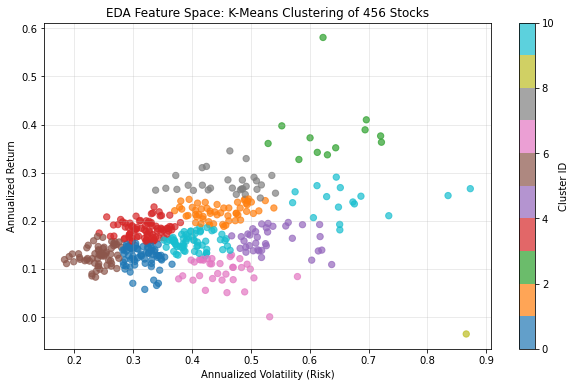

In [77]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(eda_features['Volatility'], eda_features['Return'], 
                      c=eda_features['Cluster'], cmap='tab10', alpha=0.7, s=40)

plt.title('EDA Feature Space: K-Means Clustering of 456 Stocks')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(alpha=0.3)
plt.show()

In [78]:
# Reset the index of eda_features
eda_features_reset = eda_features.reset_index().rename(columns={'index': 'Ticker'})

# Clean the tickers: Split by the space and take the first part (e.g., 'AAPL US EQUITY' -> 'AAPL')
eda_features_reset['Ticker'] = eda_features_reset['Ticker'].astype(str).str.split(' ').str[0].str.strip().str.upper()
ticker_df['Ticker'] = ticker_df['Ticker'].astype(str).str.strip().str.upper()

# Merge using 'Ticker' as the matching key
merged_df = pd.merge(eda_features_reset, ticker_df, on='Ticker', how='inner')

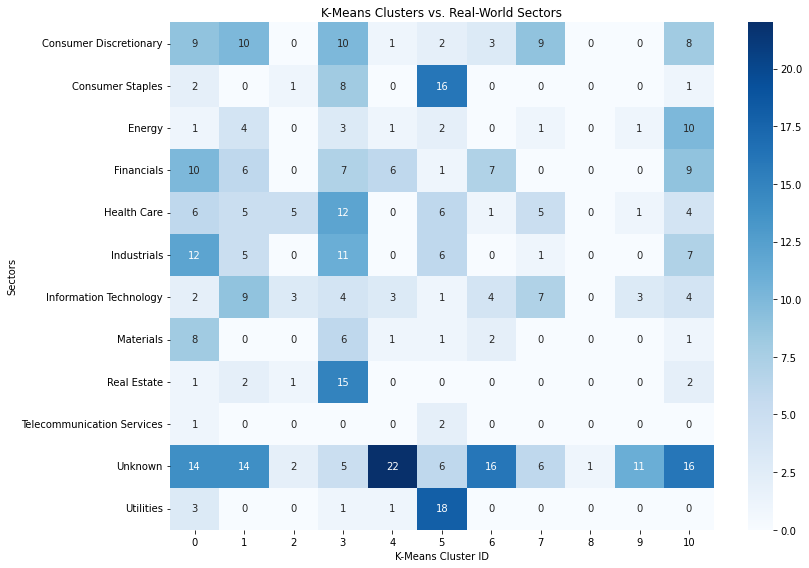

In [79]:
# Generate the cross-tab matrix
match_matrix = pd.crosstab(merged_df['Sector'], merged_df['Cluster'])

plt.figure(figsize=(12, 8))
sns.heatmap(match_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('K-Means Clusters vs. Real-World Sectors')
plt.ylabel('Sectors')
plt.xlabel('K-Means Cluster ID')
plt.tight_layout()
plt.savefig('kmeans.png', transparent=True)
plt.show()

# The Optimist

## Get dates

In [80]:
# Get available dates
dates = df_cleaned.iloc[1:, 0]
dates

905    1996-02-29
906    1996-03-01
909    1996-03-04
910    1996-03-05
911    1996-03-06
          ...    
8413   2016-09-19
8414   2016-09-20
8415   2016-09-21
8416   2016-09-22
8417   2016-09-23
Name: Date, Length: 5179, dtype: datetime64[ns]

## Get US treasury bond rate

In [81]:
early = pd.read_csv("par-yield-curve-rates-1990-1999.csv")
middle = pd.read_csv("par-yield-curve-rates-2000-2009.csv")
late = pd.read_csv("par-yield-curve-rates-2010-2019.csv")
dframes = [early, middle, late]

USTB = pd.concat(dframes)
USTB["Date"] = pd.to_datetime(USTB["Date"])
USTB.set_index("Date", inplace = True)
USTB.sort_index(inplace=True) 

# We divide by 100 to get decimal, then 252 to get daily
USTB_daily = USTB[['3 Mo']] / 100 / 252

USTB_daily.rename(columns={'3 Mo': 'daily_return'}, inplace=True)
USTB_daily

,daily_return
Date,
1990-01-02,0.000311
1990-01-03,0.000313
1990-01-04,0.000311
1990-01-05,0.000309
1990-01-08,0.000309
...,...
2019-12-24,0.000063
2019-12-26,0.000063
2019-12-27,0.000062


## Keep the dates with daily return rate

In [82]:
# Convert the Series to a DataFrame and set the dates as the index
dates_df = dates.to_frame()
dates_df.set_index('Date', inplace=True)

# Perform the inner merge
final_combined = USTB_daily.merge(dates_df, left_index=True, right_index=True, how='inner')

final_combined

,daily_return
Date,
1996-02-29,0.000199
1996-03-01,0.000198
1996-03-04,0.000199
1996-03-05,0.000199
1996-03-06,0.000200
...,...
2016-09-19,0.000012
2016-09-20,0.000012
2016-09-21,0.000009


In [83]:
final_returns = returns.merge(final_combined, left_index=True, right_index=True, how='inner')
ustb_final = final_returns.pop("daily_return")
final_returns

,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,ADP US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,0.041190,-0.009025,0.000000,0.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,0.006595,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,0.015284,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,0.000000,-0.012732,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,-0.002152,0.014251,0.026333,0.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,0.000000,0.021318,-0.011364,0.005045
1996-03-06,0.006467,-0.016432,0.008552,0.000000,-0.002890,0.000000,-0.030532,-0.028846,0.006538,-0.003214,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,0.000000,-0.006689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,-0.008476,-0.011661,-0.010106,0.001361,-0.004538,-0.008650,0.007581,0.006608,0.003568,-0.002189,...,0.007355,0.056569,0.011651,0.003590,0.002437,-0.002379,0.001509,0.005101,0.008584,0.000000
2016-09-20,0.008549,-0.000088,-0.014173,0.000000,-0.002398,0.000579,0.009430,-0.001922,-0.000710,0.014210,...,-0.005642,-0.010111,-0.003840,0.001191,-0.010469,-0.015389,-0.002512,-0.004060,-0.005957,-0.001005
2016-09-21,0.024365,-0.000176,0.011452,0.014388,0.008176,0.086626,0.071159,0.015400,0.015659,0.012416,...,0.012686,0.075718,0.024809,0.020827,0.006045,0.009207,0.005372,0.013248,0.018836,0.004020


# Apply static weight (absolute) portfolio on every stock equally

In [84]:
# Align the Price Data with the Risk-Free dates
# We use final_returns.index because that's where we have clean, overlapping data
abs_prices = df_cleaned[df_cleaned['Date'].isin(final_returns.index)].copy()
abs_prices = abs_prices.set_index('Date').iloc[:, 0:] # Ensure Date is the index

# Set Initial Setup ($1 investment, Equal Weights)
initial_investment = 1.0
num_stocks = len(abs_prices.columns)
initial_weights = np.ones(num_stocks) / num_stocks

# Buy and Hold: Calculate shares owned based on the very first day's prices
first_day_prices = abs_prices.iloc[0]
shares_owned = (initial_investment * initial_weights) / first_day_prices

# Calculate the total Portfolio Value over time
# Total Value = Sum of (Price * Shares) for all stocks
static_abs_value = abs_prices.multiply(shares_owned, axis=1).sum(axis=1)

# Calculate Daily Returns
static_abs_returns = static_abs_value.pct_change().dropna()

# Calculate Sortino
# Align Risk-Free rate to match the return dates
rf_aligned = ustb_final.loc[static_abs_returns.index]
excess_abs = static_abs_returns - rf_aligned

mean_excess = excess_abs.mean()
downside_diff = excess_abs[excess_abs < 0]
downside_std = np.sqrt(np.mean(downside_diff**2))

sortino_abs = mean_excess / (downside_std)

print(f"Sortino Ratio: {sortino_abs:.6f}")

Sortino Ratio: 0.039607


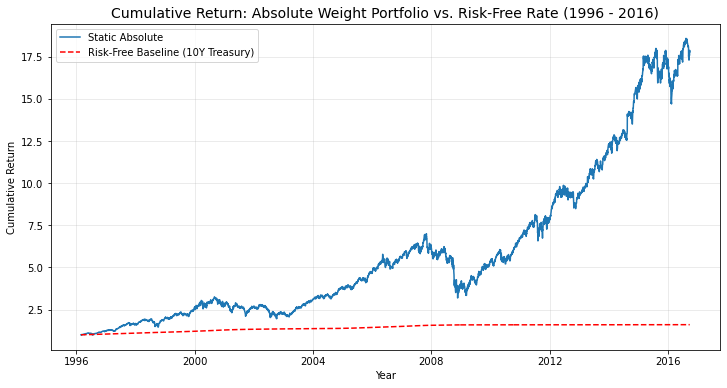

In [85]:
# Calculate Risk-Free Wealth Growth
# We start at 1.0 and multiply by (1 + rate) every day
rf_wealth = (1 + ustb_final.loc[static_abs_returns.index]).cumprod()
# Insert a '1.0' at the start to match the beginning of the portfolio
rf_wealth_series = pd.concat([pd.Series([1.0], index=[abs_prices.index[0]]), rf_wealth])

# Plotting
plt.figure(figsize=(12, 6))

# Plot the Portfolio Growth
plt.plot(static_abs_value.index, static_abs_value.values, 
         label=f'Static Absolute')

# Plot the Risk-Free Growth
plt.plot(rf_wealth_series.index, rf_wealth_series.values, 
         label='Risk-Free Baseline (10Y Treasury)', color='red', linestyle='--')

# Formatting
plt.title('Cumulative Return: Absolute Weight Portfolio vs. Risk-Free Rate (1996 - 2016)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('absolute_weight.png', transparent=True)
plt.show()

# Apply static weight (relative) portfolio on every stock equally and get sortino value

In [86]:
# Calculate Portfolio Returns using the filtered data
equal_weights = np.ones(len(final_returns.columns)) / len(final_returns.columns)
portfolio_returns = final_returns.dot(equal_weights)

# Calculate Daily Excess Returns
# This subtracts the specific risk-free rate for each day
excess_returns = portfolio_returns - ustb_final

# Calculate Sortino Components
mean_excess = excess_returns.mean()
downside_diff = excess_returns[excess_returns < 0]
downside_std = np.sqrt(np.mean(downside_diff**2))

sortino_static = mean_excess / downside_std
print(f"Static Sortino Ratio (Daily Method): {sortino_static}")

Static Sortino Ratio (Daily Method): 0.04240784690630703


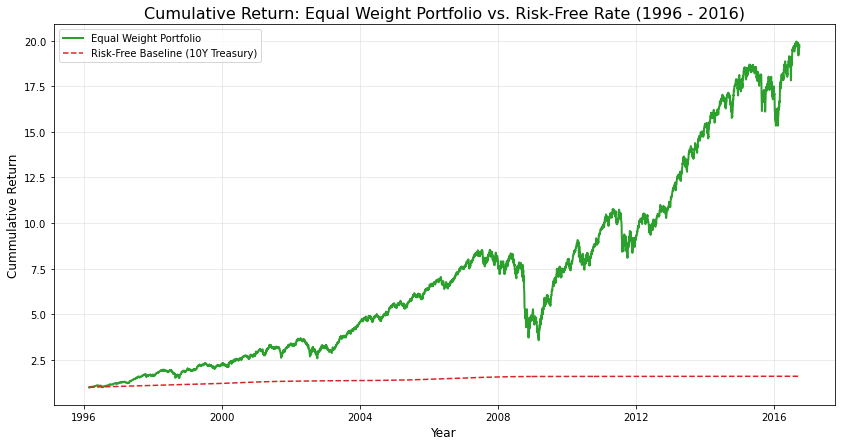

In [87]:
# Calculate Cumulative Growth (Starting from $1)
portfolio_cumulative = (1 + portfolio_returns).cumprod()
risk_free_cumulative = (1 + ustb_final).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(portfolio_cumulative, label='Equal Weight Portfolio', color='#2ca02c', linewidth=2)
plt.plot(risk_free_cumulative, label='Risk-Free Baseline (10Y Treasury)', color='#d62728', linestyle='--')

plt.title('Cumulative Return: Equal Weight Portfolio vs. Risk-Free Rate (1996 - 2016)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cummulative Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.savefig('equal_weight.png', transparent=True)
plt.show()

# Generate random weights

In [88]:
num_stocks = len(final_returns.columns)
sortino_val = []
best_sortino = -np.inf
best_ran_port = None  # This will store the actual return series of the best one

for i in range(10000): 
    # Generate and normalize random weights
    weights = np.random.uniform(0, 1, num_stocks)
    proportions = weights / weights.sum()
    
    # Calculate portfolio returns
    current_ran_port = final_returns.dot(proportions)
    
    # Apply Daily Method: Subtract the risk-free series
    excess_returns = current_ran_port - ustb_final
    
    # Sortino Calculation
    mean_excess = excess_returns.mean()
    downside_diff = excess_returns[excess_returns < 0]
    downside_std = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else 1e-10
    
    current_sortino = mean_excess / downside_std
    sortino_val.append(current_sortino)
    
    # Check if it is the best one so far
    if current_sortino > best_sortino:
        best_sortino = current_sortino
        best_ran_port = current_ran_port # Save the series for plotting

print(f"Best Random Sortino Found: {best_sortino}")

Best Random Sortino Found: 0.04466660661607247


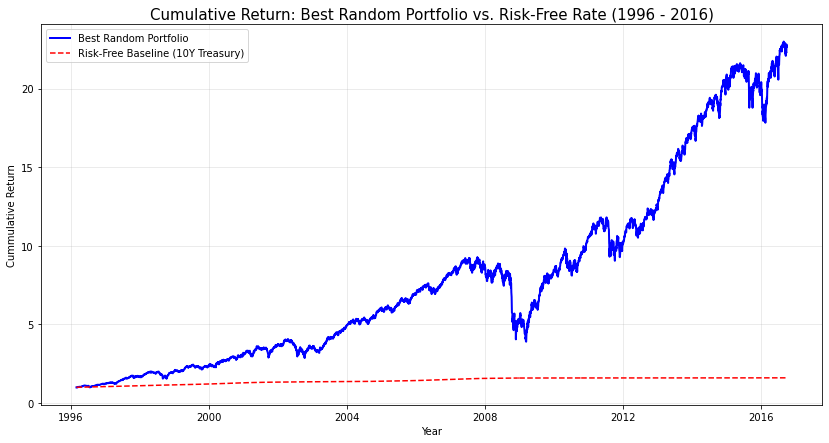

In [89]:
# Calculate Cumulative Growth
# We use .cumprod() to show how $1 grows over time
best_portfolio_cummu = (1 + best_ran_port).cumprod()
risk_free_cummu = (1 + ustb_final).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(best_portfolio_cummu, label='Best Random Portfolio', color='blue', linewidth=2)
plt.plot(risk_free_cummu, label='Risk-Free Baseline (10Y Treasury)', color='red', linestyle='--')

plt.title('Cumulative Return: Best Random Portfolio vs. Risk-Free Rate (1996 - 2016)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Cummulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('random.png', transparent=True)
plt.show()

# Optimized Method

In [90]:
# Define the objective function to MINIMIZE (Negative Sortino)
def objective(weights, returns, rf_series):
    portfolio_return = returns.dot(weights)
    excess_returns = portfolio_return - rf_series
    
    mean_excess = excess_returns.mean()
    downside_diff = excess_returns[excess_returns < 0]
    downside_std = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else 1e-10
    
    # We return the negative because the solver MINIMIZES
    return -(mean_excess / downside_std)

# Constraints: All weights must sum to 1.0
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# Bounds: No short selling (weights between 0 and 1)
bounds = [(0, 1) for _ in range(len(final_returns.columns))]
# Initial guess (Equal weighting)
init_guess = np.array([1/len(final_returns.columns)] * len(final_returns.columns))

# Run the optimizer
opt_results = minimize(objective, init_guess, args=(final_returns, ustb_final), 
                       method='SLSQP', bounds=bounds, constraints=constraints)
sortino_optimized = -opt_results.fun
print(f"Optimal Sortino: {sortino_optimized}")
optimal_weights = opt_results.x

Optimal Sortino: 0.09309780338033964


In [91]:
# Generate the daily returns of the optimized portfolio
optimized_portfolio_returns = final_returns.dot(optimal_weights)

# Calculate Total Cumulative Return
final_wealth = (1 + optimized_portfolio_returns).cumprod().iloc[-1]
cumulative_return = final_wealth - 1

# Calculate Annualized Risk (Standard Deviation)
# We multiply daily volatility by the square root of 252 trading days to annualize it
daily_volatility = optimized_portfolio_returns.std()
annualized_risk = daily_volatility * np.sqrt(252)

# This result is more of a "hypothetical limit" to what the optimized method could achieve if it knows which stocks performs well beforehand
print(f"Optimized Portfolio Cumulative Return: {cumulative_return * 100:.2f}%")
print(f"Optimized Portfolio Annualized Risk (Std Dev): {annualized_risk * 100:.2f}%")

Optimized Portfolio Cumulative Return: 32451.59%
Optimized Portfolio Annualized Risk (Std Dev): 18.86%


# Realistic application of the optimized method with different look-back windows

In [92]:
from scipy.optimize import minimize

# Make sure indices are datetime objects
final_returns.index = pd.to_datetime(final_returns.index)
ustb_final.index = pd.to_datetime(ustb_final.index)

# Define the different look-back periods you want to test
windows_to_test = [1, 3, 5]
years_in_data = sorted(final_returns.index.year.unique())

# Dictionary to store the final summary metrics
results_summary = {}

# Outer loop to test each lookback window length
for lookback_len in windows_to_test:
    rolling_portfolio_returns = []
    
    # Inner loop: Run the backtest for this specific window length
    for i in range(lookback_len, len(years_in_data)):
        current_year = years_in_data[i]
        lookback_start_year = years_in_data[i - lookback_len]
        lookback_end_year = years_in_data[i - 1]
        
        # Extract train and test slices
        train_returns = final_returns.loc[str(lookback_start_year):str(lookback_end_year)]
        train_rf = ustb_final.loc[str(lookback_start_year):str(lookback_end_year)]
        test_returns = final_returns.loc[str(current_year)]
        
        # Optimize
        bounds = [(0, 1) for _ in range(len(final_returns.columns))]
        init_guess = np.array([1/len(final_returns.columns)] * len(final_returns.columns))
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        
        opt_results = minimize(objective, init_guess, args=(train_returns, train_rf), 
                               method='SLSQP', bounds=bounds, constraints=constraints)
        
        # Evaluate out-of-sample
        year_portfolio_returns = test_returns.dot(opt_results.x)
        rolling_portfolio_returns.append(year_portfolio_returns)
        
    # Stitch this window's results together
    portfolio_series = pd.concat(rolling_portfolio_returns)
    
    # Calculate Performance Metrics
    # Cumulative Return
    cum_return = (1 + portfolio_series).prod() - 1
    
    # Annualized Risk
    ann_risk = portfolio_series.std() * np.sqrt(252)
    
    # Annualized Sortino Ratio
    excess_series = portfolio_series - ustb_final
    mean_excess = excess_series.mean()
    downside_diff = excess_series[excess_series < 0]
    downside_std = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else 1e-10
    sortino = (mean_excess / downside_std) * np.sqrt(252)
    
    # Save metrics to our dictionary
    results_summary[f"{lookback_len}-Year Window"] = {
        "Cumulative Return": f"{cum_return * 100:.2f}%",
        "Annualized Risk": f"{ann_risk * 100:.2f}%",
        "Sortino Ratio": f"{sortino:.4f}"
    }

# Display the final results neatly as a DataFrame
summary_df = pd.DataFrame(results_summary).T
print("\n======= LOOK-BACK WINDOW SENSITIVITY ANALYSIS =======")
print(summary_df)


======= LOOK-BACK WINDOW SENSITIVITY ANALYSIS =======
              Cumulative Return Annualized Risk Sortino Ratio
1-Year Window          3549.93%          20.28%        0.8602
3-Year Window          1136.62%          22.00%        0.6495
5-Year Window          1053.97%          21.10%        0.7432


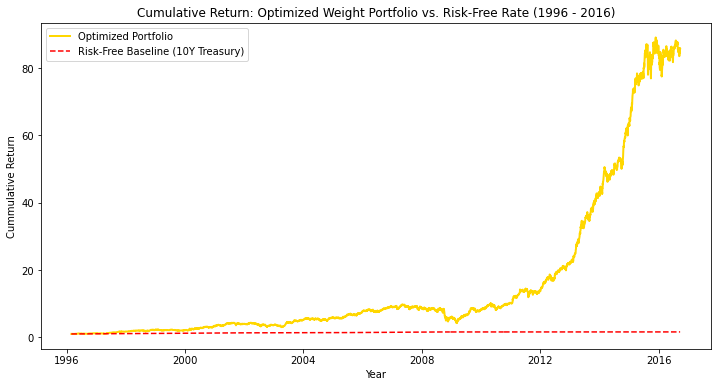

In [93]:
# Get the return series for the Optimized method
surgical_daily_returns = final_returns.dot(opt_results.x)

plt.figure(figsize=(12, 6))
plt.plot((1 + surgical_daily_returns).cumprod(), label='Optimized Portfolio', color='gold', linewidth=2)
plt.plot((1 + ustb_final).cumprod(), label='Risk-Free Baseline (10Y Treasury)', color='red', linestyle='--')
plt.title('Cumulative Return: Optimized Weight Portfolio vs. Risk-Free Rate (1996 - 2016)')
plt.xlabel('Year')
plt.ylabel('Cummulative Return')
plt.legend()
plt.savefig('plot.png', transparent=True)
plt.show()

In [94]:
# Define the split point (e.g., 80% for training, 20% for testing)
split_idx = int(len(final_returns) * 0.8)

train_returns = final_returns.iloc[:split_idx]
train_rf = ustb_final.iloc[:split_idx]

test_returns = final_returns.iloc[split_idx:]
test_rf = ustb_final.iloc[split_idx:]

# Run on the training data
opt_results_train = minimize(objective, init_guess, args=(train_returns, train_rf), 
                             method='SLSQP', bounds=bounds, constraints=constraints)

trained_weights = opt_results_train.x

# Apply the weights to the test data
test_portfolio_returns = test_returns.dot(trained_weights)
test_excess = test_portfolio_returns - test_rf

# Calculate the 'Out-of-Sample' Sortino
mean_test = test_excess.mean()
downside_test = test_excess[test_excess < 0]
std_test = np.sqrt(np.mean(downside_test**2))
out_of_sample_sortino = mean_test / std_test

print(f"In-Sample Sortino (Training): {-opt_results_train.fun:.4f}")
print(f"Out-of-Sample Sortino (Testing): {out_of_sample_sortino:.4f}")

In-Sample Sortino (Training): 0.0959
Out-of-Sample Sortino (Testing): 0.0809


# Dynamic Portfolio

In [95]:
window = 30
dynamic_portfolio_returns = []

# Loop through the data to rebalance based on past performance
for t in range(window, len(final_returns)):
    # Look at the past window to decide weights
    past_perf = final_returns.iloc[t-window:t]
    
    # Optimist Logic: weight stocks by their past mean return
    scores = past_perf.mean()
    scores = scores - scores.min() # ensure non-negative
    weights = scores / (scores.sum() + 1e-10)
    
    # Apply those weights to 'today'
    today_return = final_returns.iloc[t].dot(weights)
    dynamic_portfolio_returns.append(today_return)

# Convert list to Series and match the index of ustb_final
dynamic_series = pd.Series(dynamic_portfolio_returns, index=final_returns.index[window:])
rf_subset = ustb_final.iloc[window:]

# Apply Daily Method to the dynamic results
dynamic_excess = dynamic_series - rf_subset

# Calculate Final Sortino
mean_dyn = dynamic_excess.mean()
downside_dyn = dynamic_excess[dynamic_excess < 0]
downside_std_dyn = np.sqrt(np.mean(downside_dyn**2))

sortino_dynamic = mean_dyn / downside_std_dyn
print(f"Dynamic Sortino Ratio: {sortino_dynamic}")

Dynamic Sortino Ratio: 0.03928453890404032


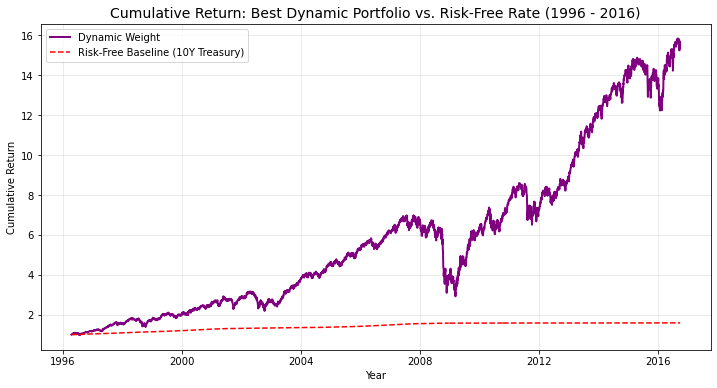

In [101]:
# Calculate Cumulative Growth
# We start both at 1.0 on the first day the dynamic strategy is active
dynamic_growth = (1 + dynamic_series).cumprod()
rf_dynamic_growth = (1 + rf_subset).cumprod()

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(dynamic_growth.index, dynamic_growth.values, 
         label=f'Dynamic Weight', 
         color='purple', linewidth=2)

plt.plot(rf_dynamic_growth.index, rf_dynamic_growth.values, 
         label='Risk-Free Baseline (10Y Treasury)', 
         color='red', linestyle='--')

plt.title('Cumulative Return: Best Dynamic Portfolio vs. Risk-Free Rate (1996 - 2016)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('dynamic.png', transparent=True)
plt.show()

# Portfolio strategy comparison

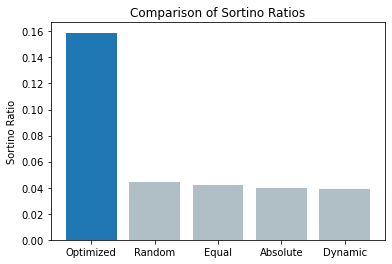

In [97]:
strategies = ['Absolute', 'Equal', 'Random', 'Dynamic', 'Optimized']
sortino_methods = [sortino_abs, sortino_static, best_sortino, sortino_dynamic, -opt_results.fun]

# Sort from highest to lowest Sortino ratio automatically
sorted_pairs = sorted(zip(strategies, sortino_methods), key=lambda x: x[1], reverse=True)
x_labels, y_values = zip(*sorted_pairs)

colors = ['#1f77b4' if x == 'Optimized' else '#b0bec5' for x in x_labels]
plt.bar(x_labels, y_values, color=colors)

plt.title('Comparison of Sortino Ratios')
plt.ylabel('Sortino Ratio')
plt.savefig('sortino_comparison.png', transparent=True)

# Cumulative return of all methods

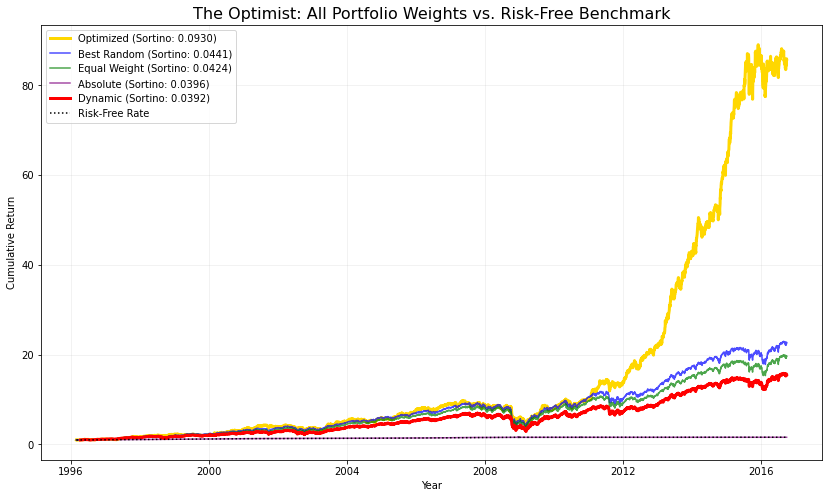

In [98]:
plt.figure(figsize=(14, 8))

# Cumulative Growth of $1
plt.plot((1 + surgical_daily_returns).cumprod(), label='Optimized (Sortino: 0.0930)', color='gold', linewidth=3)
plt.plot((1 + best_ran_port).cumprod(), label='Best Random (Sortino: 0.0441)', color='blue', alpha=0.7)
plt.plot((1 + portfolio_returns).cumprod(), label='Equal Weight (Sortino: 0.0424)', color='green', alpha=0.7)
plt.plot((1 + ustb_final.loc[static_abs_returns.index]).cumprod(), label='Absolute (Sortino: 0.0396)', color='purple', alpha=0.7)
plt.plot((1 + dynamic_series).cumprod(), label='Dynamic (Sortino: 0.0392)', color='red', linewidth=3)
plt.plot((1 + ustb_final).cumprod(), label='Risk-Free Rate', color='black', linestyle=':')

plt.title('The Optimist: All Portfolio Weights vs. Risk-Free Benchmark', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig('comparison.png', transparent=True)
plt.show()

# Comparison of cumulative return and risk between all investor profiles

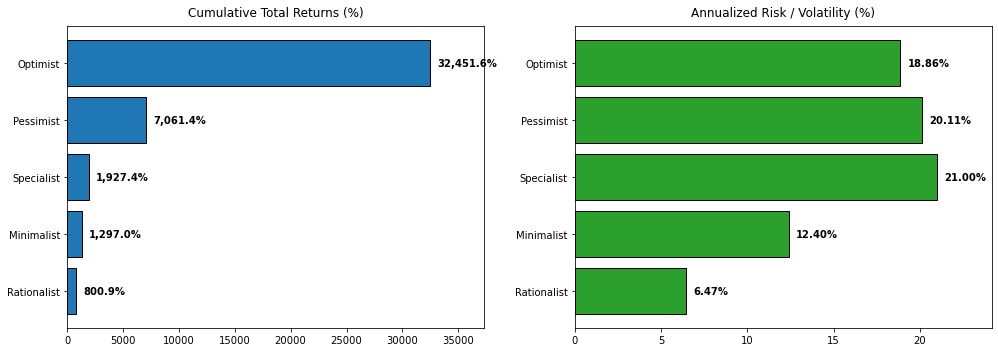

In [99]:
profiles = ['Rationalist', 'Minimalist', 'Specialist', 'Pessimist', 'Optimist']
returns = [800.88, 1297.00, 1927.43, 7061.38, 32451.59]
risk = [6.47, 12.40, 21.00, 20.11, 18.86]

# Create plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative Returns
ax1.barh(profiles, returns, color='#1f77b4', edgecolor='black')
ax1.set_title('Cumulative Total Returns (%)', pad=10)
ax1.set_xlim(0, max(returns) * 1.15)  # <-- This adds 15% padding to the right border
for i, v in enumerate(returns):
    ax1.text(v + (max(returns) * 0.02), i, f"{v:,.1f}%", va='center', fontweight='bold')

# Plot 2: Annualized Risk
ax2.barh(profiles, risk, color='#2ca02c', edgecolor='black')
ax2.set_title('Annualized Risk / Volatility (%)', pad=10)
ax2.set_xlim(0, max(risk) * 1.15)  # <-- This adds 15% padding to the right border
for i, v in enumerate(risk):
    ax2.text(v + (max(risk) * 0.02), i, f"{v:.2f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_final.png', transparent=True)
plt.show()